In [10]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers, callbacks, utils
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df=pd.read_csv("combined_air_quality_modified.csv")
df = df.sort_values('date')
df.head()

,country,date,county,sitename,aqi,status,pm2.5,pm10,no,no2,nox,co,so2,o3,siteid
0,Philippines,2014-01-01,NCR,Manila,118.0,Unhealthy for Sensitive Groups,42.450712,105.388892,18.993939,68.680839,46.467632,1.180798,23.094493,12.319120,NaN
4176,Philippines,2014-01-01,Region II (Cagayan Valley),Cauayan,75.0,Moderate,23.586933,37.758559,18.139599,25.207036,22.973716,0.817300,7.100486,42.524681,NaN
9936,Philippines,2014-01-01,Region V (Bicol),Sorsogon City,63.0,Moderate,17.866673,37.519276,12.653516,18.765847,16.652262,0.892755,9.208096,40.003560,NaN
10080,Philippines,2014-01-01,Region V (Bicol),Masbate City,79.0,Moderate,25.350025,45.701587,9.424173,31.094817,21.475065,1.174867,14.641140,58.184813,NaN
4032,Philippines,2014-01-01,Region II (Cagayan Valley),Santiago,59.0,Moderate,15.811384,29.334256,9.228539,16.178484,13.465722,0.422890,5.918269,15.714872,NaN


In [12]:
features=['so2','co','o3','pm2.5','pm10','no2','nox','no']

status=['aqi']
X=df[features]
y=df[status]  


In [13]:
unique_dates = df['date'].unique()
split_idx = int(len(unique_dates) * 0.8)
train_dates = unique_dates[:split_idx]

df_train = df[df['date'].isin(train_dates)].copy()
df_test = df[~df['date'].isin(train_dates)].copy()

In [14]:
scaler = StandardScaler()
df_train[features] = scaler.fit_transform(df_train[features])
df_test[features] = scaler.transform(df_test[features])

def create_sequences_by_station(dataframe, feature_cols, window_size=24):
    X_seq, y_seq = [], []
    # Group by station name to keep timelines fully isolated
    for station, group in dataframe.groupby('sitename'):
        group_sorted = group.sort_values('date')
        group_features = group_sorted[feature_cols].values
        group_targets = group_sorted['aqi'].values
        
        if len(group_sorted) > window_size:
            for i in range(len(group_sorted) - window_size):
                X_seq.append(group_features[i : (i + window_size)])
                y_seq.append(group_targets[i + window_size])
                
    return np.array(X_seq), np.array(y_seq)

# Build valid 3D shapes representing (Samples, 24 Hours, 8 Features)
X_train_seq, y_train_seq = create_sequences_by_station(df_train, features, window_size=24)
X_test_seq, y_test_seq = create_sequences_by_station(df_test, features, window_size=24)

print("Clean Train Sequence Shape:", X_train_seq.shape)
print("Clean Test Sequence Shape:", X_test_seq.shape)

Clean Train Sequence Shape: (112253, 24, 8)
Clean Test Sequence Shape: (24349, 24, 8)


In [15]:
model = tf.keras.Sequential([
# Input shape: (Time Steps, Features)
    layers.Input(shape=(24, 8)), 
    
    # First GRU layer 
    layers.GRU(128, return_sequences=True),
    layers.BatchNormalization(), 
    layers.Dropout(0.4),
    
    # First GRU layer 
    layers.GRU(256, return_sequences=True),
    layers.BatchNormalization(), 
    layers.Dropout(0.3),
    

    # Third GRU layer
    layers.GRU(64),
    layers.BatchNormalization(),
    layers.Dropout(0.2),


    # Output Layer
    layers.Dense(1, activation='linear')
])

In [16]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mae',
    metrics=['mae','mse'

    ]
)

In [17]:
# callback for saving checkpoint and early stop
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6
)

my_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    callbacks.ModelCheckpoint(filepath='phT_best_model_svm_regressor.keras', monitor='val_loss', save_best_only=True),
    reduce_lr
]

In [18]:
model.fit(
X_train_seq, y_train_seq,
epochs=100,
batch_size=256,
shuffle=True,
validation_split=0.2,
verbose=1,
callbacks=my_callbacks
)#training nn

Epoch 1/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 90s 239ms/step - loss: 33.4260 - mae: 33.4260 - mse: 1512.3420 - val_loss: 26.6175 - val_mae: 26.6175 - val_mse: 877.5758 - learning_rate: 5.0000e-04
Epoch 2/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 77s 220ms/step - loss: 23.4000 - mae: 23.4000 - mse: 951.0906 - val_loss: 11.3699 - val_mae: 11.3699 - val_mse: 214.6555 - learning_rate: 5.0000e-04
Epoch 3/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 74s 210ms/step - loss: 8.8494 - mae: 8.8494 - mse: 244.5994 - val_loss: 5.0545 - val_mae: 5.0545 - val_mse: 48.5086 - learning_rate: 5.0000e-04
Epoch 4/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 75s 213ms/step - loss: 5.5948 - mae: 5.5948 - mse: 110.7685 - val_loss: 2.6308 - val_mae: 2.6308 - val_mse: 26.1622 - learning_rate: 5.0000e-04
Epoch 5/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 74s 212ms/step - loss: 5.4360 - mae: 5.4360 - mse: 105.7605 - val_loss: 2.3172 - val_mae: 2.3172 - val_mse: 24.5698 - learning_rate: 5.0000e-04
Epoch 6/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 74s 212ms/step - loss: 

In [20]:
best_model=tf.keras.models.load_model("phT_best_model_svm_regressor.keras")
nn_pseudo_labels = best_model.predict(X_train_seq)
y_pseudo_train = nn_pseudo_labels.flatten()


X_train_flat = X_train_seq.reshape(X_train_seq.shape[0], -1)
X_test_flat_sequences = X_test_seq.reshape(X_test_seq.shape[0], -1)


# Train SVM on the extracted features
svm_model = LinearSVR(dual=False,max_iter=2000,random_state=20, loss="squared_epsilon_insensitive")
svm_model.fit(X_train_flat, y_pseudo_train)

# Evaluate SVM
y_pred_svm = svm_model.predict(X_test_flat_sequences)
print("\n--- Corrected SVM Performance ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_seq, y_pred_svm):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_seq, y_pred_svm):.4f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test_seq, y_pred_svm)):.4f}")
print(f"R-squared (R2) Variance Score: {r2_score(y_test_seq, y_pred_svm):.4f}")

3508/3508 ━━━━━━━━━━━━━━━━━━━━ 61s 17ms/step

--- Corrected SVM Performance ---
Mean Absolute Error (MAE): 3.5976
Mean Squared Error (MSE): 27.4668
Root Mean Squared Error (RMSE): 5.2409
R-squared (R2) Variance Score: 0.8834


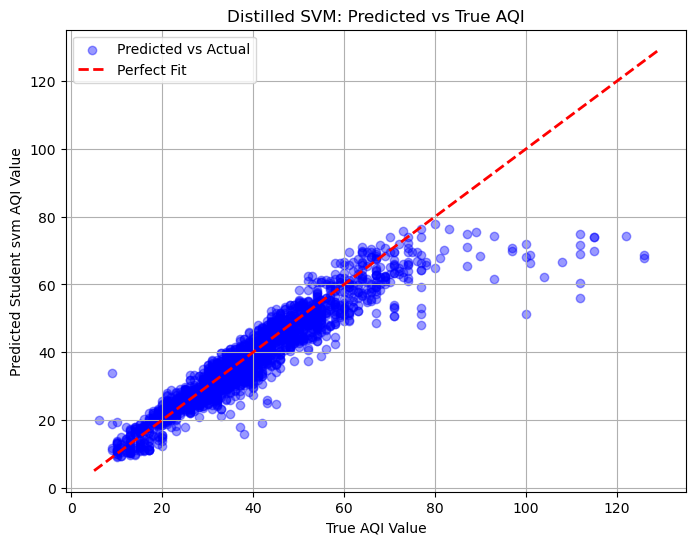

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_seq[:2000], y_pred_svm[:2000], alpha=0.4, color='b', label='Predicted vs Actual')

# Plot accurate perfect diagonal trendline boundary
perfect_line = [min(y_test_seq), max(y_test_seq)]
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.xlabel('True AQI Value')
plt.ylabel('Predicted Student svm AQI Value')
plt.title('Distilled SVM: Predicted vs True AQI')
plt.legend()
plt.grid(True)
plt.savefig('regression_fit_perf.png')

In [22]:
import joblib

# 1. Save the Trained Student Random Forest Regressor
# Using compress=3 reduces file size significantly on your disk
joblib.dump(svm_model, 'phT_distilled_SVM_regressor.pkl', compress=3)
print("✅ Student Random Forest Model successfully saved as 'distilled_random_forest_regressor.pkl'")

# 2. Save the Standard Scaler (Crucial for transforming new deployment inputs correctly)
joblib.dump(scaler, 'phT_aqi_scaler_SVM.pkl')
print("✅ Feature Scaler successfully saved as 'aqi_scaler.pkl'")

# 3. Save the Trained Teacher GRU Deep Learning Model
# Keras models should be saved in native .keras format
model.save('phT_teacher_gru_regressor.keras')
print("✅ Teacher GRU Deep Learning Model successfully saved as 'teacher_gru_regressor.keras'")

✅ Student Random Forest Model successfully saved as 'distilled_random_forest_regressor.pkl'
✅ Feature Scaler successfully saved as 'aqi_scaler.pkl'
✅ Teacher GRU Deep Learning Model successfully saved as 'teacher_gru_regressor.keras'
